In [2]:
from bertopic import BERTopic
import pandas as pd
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from spacy.lang.es.stop_words import STOP_WORDS
import pickle
import json
import matplotlib as plt
import os
import plotly.express as px
import numpy as np
from typing import List, Union
from bertopic.representation import KeyBERTInspired




In [3]:
file_path = r"C:\Users\karen\Documents\analisis_columnas_opinion_git\data\processed\corpus_date_formatted.xlsx"
corpus = pd.read_excel(file_path, engine='openpyxl')

In [4]:
corpus.head(2)

,Diario,Autor,Fecha,Título,Texto,Vínculo,ID
0,El Espectador,Gonzalo Hernández,2018-01-01,Fajardo: para nada tibio,"La Coalición Colombia –Partido Alianza Verde, ...",https://web.archive.org/web/20180102104221/htt...,1
1,El Espectador,Eduardo Barajas Sandoval,2018-01-01,Macedonia de Norte,Las interpretaciones de la historia sirven com...,https://web.archive.org/web/20180102104221/htt...,2


In [3]:
sentence_model = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased")

In [4]:
texto_seleccionado = corpus['Texto'][10000:].astype(str).tolist()

In [29]:
# zeroshot topics
# We define a number of topics that we know are in the documents
zeroshot_topic_list = ["Ciencias exactas y naturales y de salud y cientificos y organizaciones cientificas"]

# We fit our model using the zero-shot topics
# and we define a minimum similarity. For each document,
# if the similarity does not exceed that value, it will be used
# for clustering instead.
topic_model = BERTopic(
    language="spanish",
    embedding_model= sentence_model,
    min_topic_size=15,
    zeroshot_topic_list=zeroshot_topic_list,
    zeroshot_min_similarity=.85,
    vectorizer_model=TfidfVectorizer(stop_words=list(STOP_WORDS)),
    representation_model=KeyBERTInspired()
)
topics, probs = topic_model.fit_transform(texto_seleccionado)

In [ ]:
topic_model = BERTopic(language="spanish",
    top_n_words=3,          # Palabras por tópico
    min_topic_size=20,       # Tamaño mínimo del cluster
    nr_topics=50,        # Número de tópicos
    calculate_probabilities=True,
    vectorizer_model=TfidfVectorizer(stop_words=list(STOP_WORDS)),
    embedding_model= sentence_model
    )

In [52]:
# Este tarda 12 minutos
topics, probs = topic_model.fit_transform(texto_seleccionado)

In [53]:
topic_distr, _ = topic_model.approximate_distribution(texto_seleccionado, batch_size=500, window=10)


In [8]:
model_path = r"C:\Users\karen\Documents\analisis_columnas_opinion_git\models"
os.makedirs(model_path, exist_ok=True)  # Crea la carpeta si no existe


In [30]:
textos_topico_0 = [texto for texto, topico in zip(texto_seleccionado, topics) if topico == 0]


In [31]:
import pprint
pprint.pprint(textos_topico_0[0])

('Una cosa son las intenciones y las estrategias y otra las percepciones que '
 'se generan en la opinión pública. El presidente y el Gobierno jugando a las '
 'escondidas con la minga; las respuestas que esquivan la verdad; los '
 'problemas, escudándose en las cifras del pasado; un Congreso que, disfrazado '
 'de legalidad, anula el juego político de la democracia. Estas y tantas cosas '
 'más están logrando que la desconfianza cabalgue desaforadamente. Tal vez se '
 'podrá estar actuando con magnanimidad y responsabilidad, pero mientras eso '
 'no se proyecte en los ciudadanos que no logran entender por dónde va el agua '
 'al molino, poco se logrará avanzar en el propósito de la convivencia, la paz '
 'y la reactivación económica. Lo que surge a la superficie es que el Gobierno '
 'está dando palos de ciego, está perdido o no logra transmitir qué es lo que '
 'busca. El desgaste de la retórica hueca es más que evidente.\n'
 '\n'
 'Confucio, en las Analectas XII-7, dice lo siguiente

In [43]:
# Guardar los tópicos asignados a cada documento
with open(os.path.join(model_path, 'topics_bert.json'), 'w', encoding='utf-8') as f:
    json.dump(topics, f, ensure_ascii=False, indent=4)

# Convertir probabilidades a lista antes de guardar
probs_list = probs.tolist() if isinstance(probs, np.ndarray) else probs
with open(os.path.join(model_path, 'probs_bert.json'), 'w', encoding='utf-8') as f:
    json.dump(probs_list, f, ensure_ascii=False, indent=4)

# Guardar el modelo completo de BERTopic
with open(os.path.join(model_path, "topic_model.pkl"), "wb") as f:
    pickle.dump(topic_model, f)

In [44]:
# CARGAR  modelo, probabilidades y tópicos
# Cargar el modelo
with open(os.path.join(model_path, "topic_model.pkl"), "rb") as f:
    topic_model = pickle.load(f)

# Cargar asignaciones y probabilidades
with open(os.path.join(model_path, 'topics_bert.json'), 'r', encoding='utf-8') as f:
    topics = json.load(f)

with open(os.path.join(model_path, 'probs_bert.json'), 'r', encoding='utf-8') as f:
    probs = json.load(f)

In [28]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3,-1_necesidad_votación_humanidad_ciudades,"[necesidad, votación, humanidad, ciudades, cer...",[La pandemia del COVID-19 es apenas un campana...
1,0,3586,0_elecciones_constitución_constitucional_segur...,"[elecciones, constitución, constitucional, seg...",[Me parece que el doctor Vargas Lleras se vuel...
2,1,87,1_seguridad_colombianos_realidad_protección,"[seguridad, colombianos, realidad, protección,...",[La pandemia de covid-19 crece exponencialment...


In [8]:
# Obtener información de tópicos
topic_info = topic_model.get_topic_info()

# Filtrar outliers (tópico -1)
topic_info_filtered = topic_info[topic_info['Topic'] != -1]


# Gráfico de barras interactivo
fig = px.bar(topic_info,
             x='Topic',
             y='Count',
             color='Name',
             hover_data=['Representation'],
             title='Distribución de Tópicos',
             labels={'Count': 'N° Columnas', 'Name': 'Palabras Clave'},
             height=600)
fig.update_layout(xaxis={'type': 'category'})
fig.show()

In [57]:
fig = topic_model.visualize_topics()
fig.show()

In [9]:
fig = topic_model.visualize_barchart(top_n_topics=10)
fig.show()

In [10]:
fig = topic_model.visualize_hierarchy()
fig.show()

In [59]:
fig = topic_model.visualize_heatmap()
fig.show()

## Dinámico

https://maartengr.github.io/BERTopic/getting_started/topicsovertime/topicsovertime.html#visualization

In [ ]:
topics_over_time = topic_model.topics_over_time(texto_seleccionado, corpus['Fecha'], nr_bins=36)


In [ ]:
fig = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=20)
fig.show()

## Filtrar visualización de tópicos dinámica por tiempo

texto

In [ ]:
fig = topic_model.visualize_topics_over_time(topics_over_time, topics=[7])
fig.show()


<Axes: xlabel='Timestamp'>

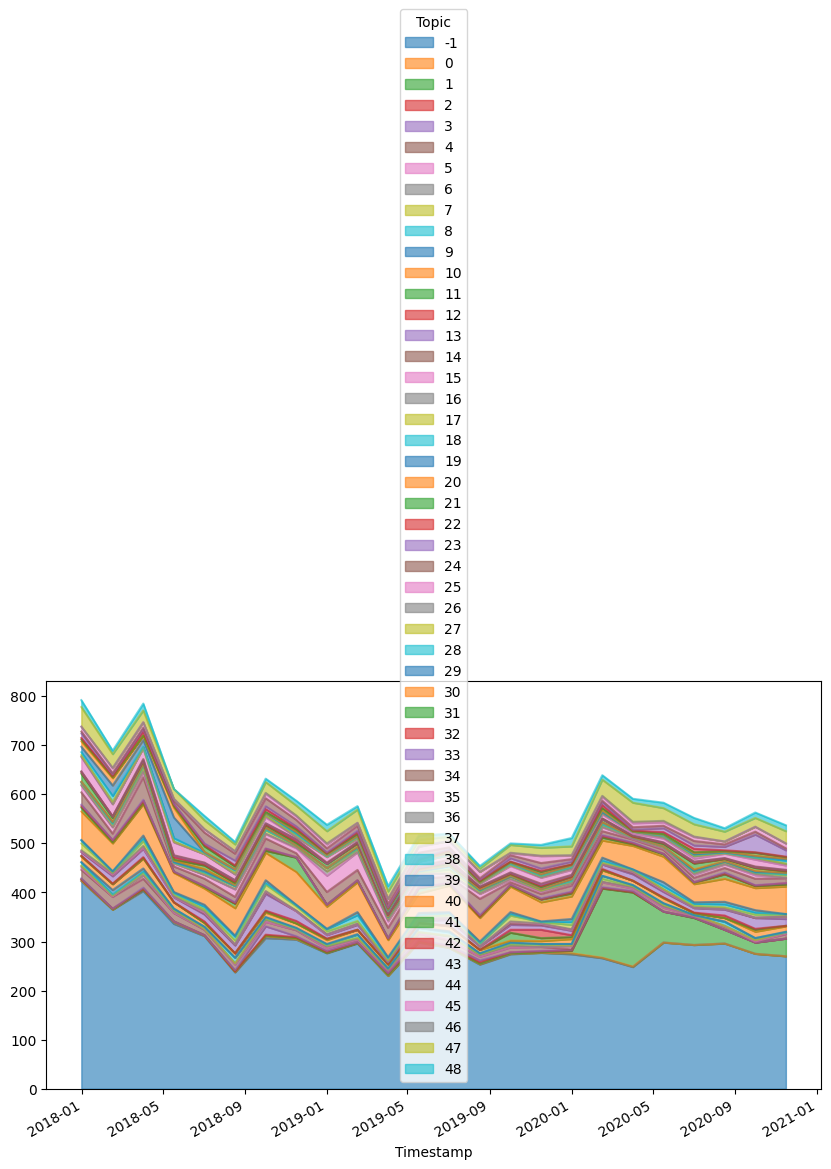

In [ ]:
df = topics_over_time.pivot(index="Timestamp", columns="Topic", values="Frequency").fillna(0)

df.plot.area(alpha=0.6, figsize=(10,6))
